# Instalação e importação das bibliotecas

Instalação das bibliotecas se necessário

In [88]:
!pip install numpy pandas matplotlib seaborn 

Import bibliotecas com alias convencionais.

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# EDA

## Carregando dados
Utilização da biblioteca pandas para leitura dos dados

In [90]:
df_salarios = pd.read_csv(r'./Dados/Salarios_dep_carg_query_1.csv')
df_media_salario = pd.read_csv(r'./Dados/Media_salarios_dep_carg.csv')
df_salario_localizacao = pd.read_csv(r'./Dados/Salarios_localizacao_query_2.csv')
df_media_salario_localizacao = pd.read_csv(r'./Dados/Media_salarios_localizacao.csv')

Prévisualização dos dados para conferencia da importação correta

In [91]:
df_salarios.head(10)

,ID,DEPARTAMENTO,CARGOS,SALARIO
0,100,Executive,President,24000
1,102,Executive,Administration Vice President,17000
2,101,Executive,Administration Vice President,17000
3,145,Sales,Sales Manager,14000
4,146,Sales,Sales Manager,13500
5,201,Marketing,Marketing Manager,13000
6,108,Finance,Finance Manager,12008
7,205,Accounting,Accounting Manager,12008
8,147,Sales,Sales Manager,12000
9,168,Sales,Sales Representative,11500


In [92]:
df_media_salario

,DEPARTAMENTO,CARGOS,MÉDIA_SALARIAL
0,Executive,President,24000.000000
1,Executive,Administration Vice President,17000.000000
2,Marketing,Marketing Manager,13000.000000
3,Sales,Sales Manager,12200.000000
4,Accounting,Accounting Manager,12008.000000
5,Finance,Finance Manager,12008.000000
6,Purchasing,Purchasing Manager,11000.000000
7,Public Relations,Public Relations Representative,10000.000000
8,Sales,Sales Representative,8396.551724
9,Accounting,Public Accountant,8300.000000


In [93]:
df_salario_localizacao.head(10)


,ID,DEPARTAMENTO,CARGOS,CIDADE,PAIS,REGIAO,SALARIO
0,100,Executive,President,Seattle,United States of America,Americas,24000
1,101,Executive,Administration Vice President,Seattle,United States of America,Americas,17000
2,102,Executive,Administration Vice President,Seattle,United States of America,Americas,17000
3,145,Sales,Sales Manager,Oxford,United Kingdom of Great Britain and Northern I...,Europe,14000
4,146,Sales,Sales Manager,Oxford,United Kingdom of Great Britain and Northern I...,Europe,13500
5,201,Marketing,Marketing Manager,Toronto,Canada,Americas,13000
6,108,Finance,Finance Manager,Seattle,United States of America,Americas,12008
7,205,Accounting,Accounting Manager,Seattle,United States of America,Americas,12008
8,147,Sales,Sales Manager,Oxford,United Kingdom of Great Britain and Northern I...,Europe,12000
9,168,Sales,Sales Representative,Oxford,United Kingdom of Great Britain and Northern I...,Europe,11500


In [94]:
df_media_salario_localizacao

,DEPARTAMENTO,CARGOS,CIDADE,PAIS,REGIAO,MEDIA_SALARIAL
0,Executive,President,Seattle,United States of America,Americas,24000.00
1,Executive,Administration Vice President,Seattle,United States of America,Americas,17000.00
2,Marketing,Marketing Manager,Toronto,Canada,Americas,13000.00
3,Sales,Sales Manager,Oxford,United Kingdom of Great Britain and Northern I...,Europe,12200.00
4,Accounting,Accounting Manager,Seattle,United States of America,Americas,12008.00
5,Finance,Finance Manager,Seattle,United States of America,Americas,12008.00
6,Purchasing,Purchasing Manager,Seattle,United States of America,Americas,11000.00
7,Public Relations,Public Relations Representative,Munich,Germany,Europe,10000.00
8,Sales,Sales Representative,Oxford,United Kingdom of Great Britain and Northern I...,Europe,8396.55
9,Accounting,Public Accountant,Seattle,United States of America,Americas,8300.00


## ADA

### df_salarios

In [95]:

df_salarios.info()
df_salarios.value_counts()


<class 'pandas.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ID            106 non-null    int64
 1   DEPARTAMENTO  106 non-null    str  
 2   CARGOS        106 non-null    str  
 3   SALARIO       106 non-null    int64
dtypes: int64(2), str(2)
memory usage: 3.4 KB


ID   DEPARTAMENTO  CARGOS                         SALARIO
100  Executive     President                      24000      1
102  Executive     Administration Vice President  17000      1
101  Executive     Administration Vice President  17000      1
145  Sales         Sales Manager                  14000      1
146  Sales         Sales Manager                  13500      1
                                                            ..
135  Shipping      Stock Clerk                    2400       1
127  Shipping      Stock Clerk                    2400       1
136  Shipping      Stock Clerk                    2200       1
128  Shipping      Stock Clerk                    2200       1
132  Shipping      Stock Clerk                    2100       1
Name: count, Length: 106, dtype: int64

Podemos ver que não há nulos, existem 2 dados categóricos e um numérico, há mais cargos em vendas que em outros departamentos

In [96]:
print(df_salarios["CARGOS"].value_counts())
print("-"*35)
print(df_salarios["DEPARTAMENTO"].value_counts())
print("-"*35)
print(df_salarios[["CARGOS", "DEPARTAMENTO"]].value_counts())

CARGOS
Sales Representative               29
Shipping Clerk                     20
Stock Clerk                        20
Sales Manager                       5
Programmer                          5
Accountant                          5
Stock Manager                       5
Purchasing Clerk                    5
Administration Vice President       2
President                           1
Marketing Manager                   1
Finance Manager                     1
Accounting Manager                  1
Purchasing Manager                  1
Public Relations Representative     1
Public Accountant                   1
Human Resources Representative      1
Marketing Representative            1
Administration Assistant            1
Name: count, dtype: int64
-----------------------------------
DEPARTAMENTO
Shipping            45
Sales               34
Finance              6
Purchasing           6
IT                   5
Executive            3
Marketing            2
Accounting           2
Public Relat

Podemos ver que o departamento de Shiping é o maior, seguido pelo de vendas

In [97]:
print(df_salarios.describe())
Q1 = df_salarios["SALARIO"].quantile(0.25)
Q3 = df_salarios["SALARIO"].quantile(0.75)
IQR = Q3 - Q1
print(f"O IQR é de {IQR}")

               ID       SALARIO
count  106.000000    106.000000
mean   152.764151   6456.754717
std     31.083161   3927.798234
min    100.000000   2100.000000
25%    126.250000   3100.000000
50%    152.500000   6150.000000
75%    179.750000   8950.000000
max    206.000000  24000.000000
O IQR é de 5850.0


**Analise da coluna salario:**
 Média e mediana estão próximas, porém o desbio padrão é bem grande, demonstrando uma grande diferença entre os valores, podemos já notar que há outliers já que o valor max é de 24000 enquanto 75% dos dados estão até 8950.

In [98]:
limite_superior = Q3 + (1.5 * IQR)
outliers = df_salarios[df_salarios["SALARIO"] > limite_superior]
print(outliers)

    ID DEPARTAMENTO     CARGOS  SALARIO
0  100    Executive  President    24000


Podemos ver que o unico oulier é o presidente, o que faz sentido

In [99]:
# Analisando duplicadas
print(f"Total de linhas duplicadas: {df_salarios.duplicated().sum()}")
duplicadas = df_salarios[df_salarios.duplicated()]
print(duplicadas)

Total de linhas duplicadas: 0
Empty DataFrame
Columns: [ID, DEPARTAMENTO, CARGOS, SALARIO]
Index: []


### df_salario_localizacao

In [100]:
df_salario_localizacao.info()
df_salario_localizacao.value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ID            106 non-null    int64
 1   DEPARTAMENTO  106 non-null    str  
 2   CARGOS        106 non-null    str  
 3   CIDADE        106 non-null    str  
 4   PAIS          106 non-null    str  
 5   REGIAO        106 non-null    str  
 6   SALARIO       106 non-null    int64
dtypes: int64(2), str(5)
memory usage: 5.9 KB


ID   DEPARTAMENTO  CARGOS                         CIDADE               PAIS                                                  REGIAO    SALARIO
100  Executive     President                      Seattle              United States of America                              Americas  24000      1
101  Executive     Administration Vice President  Seattle              United States of America                              Americas  17000      1
102  Executive     Administration Vice President  Seattle              United States of America                              Americas  17000      1
145  Sales         Sales Manager                  Oxford               United Kingdom of Great Britain and Northern Ireland  Europe    14000      1
146  Sales         Sales Manager                  Oxford               United Kingdom of Great Britain and Northern Ireland  Europe    13500      1
                                                                                                                     

Podemos ver que não há nulos, existem 5 dados categóricos e 1 numérico, há mais cargos em vendas de oxford que em outros departamentos

Como a coluna salário é a mesma não há necessidade de analisarmos novamente.

In [101]:
print(df_salario_localizacao["CIDADE"].value_counts())
print("-"*35)
print(df_salario_localizacao["PAIS"].value_counts())
print("-"*35)
print(df_salario_localizacao["REGIAO"].value_counts())
print("-"*35)
print(df_salario_localizacao[["CIDADE", "PAIS", "REGIAO"]].value_counts())

CIDADE
South San Francisco    45
Oxford                 34
Seattle                18
Southlake               5
Toronto                 2
Munich                  1
London                  1
Name: count, dtype: int64
-----------------------------------
PAIS
United States of America                                68
United Kingdom of Great Britain and Northern Ireland    35
Canada                                                   2
Germany                                                  1
Name: count, dtype: int64
-----------------------------------
REGIAO
Americas    70
Europe      36
Name: count, dtype: int64
-----------------------------------
CIDADE               PAIS                                                  REGIAO  
South San Francisco  United States of America                              Americas    45
Oxford               United Kingdom of Great Britain and Northern Ireland  Europe      34
Seattle              United States of America                              Americas

Podemos ver que mais da metade dos funcionarios da empresa são dos EUA, sendo maior parte de South San Francisco.

In [102]:
# Analisando duplicadas
print(f"Total de linhas duplicadas: {df_salario_localizacao.duplicated().sum()}")
duplicadas = df_salario_localizacao[df_salario_localizacao.duplicated()]
print(duplicadas)

Total de linhas duplicadas: 0
Empty DataFrame
Columns: [ID, DEPARTAMENTO, CARGOS, CIDADE, PAIS, REGIAO, SALARIO]
Index: []


# Gráficos

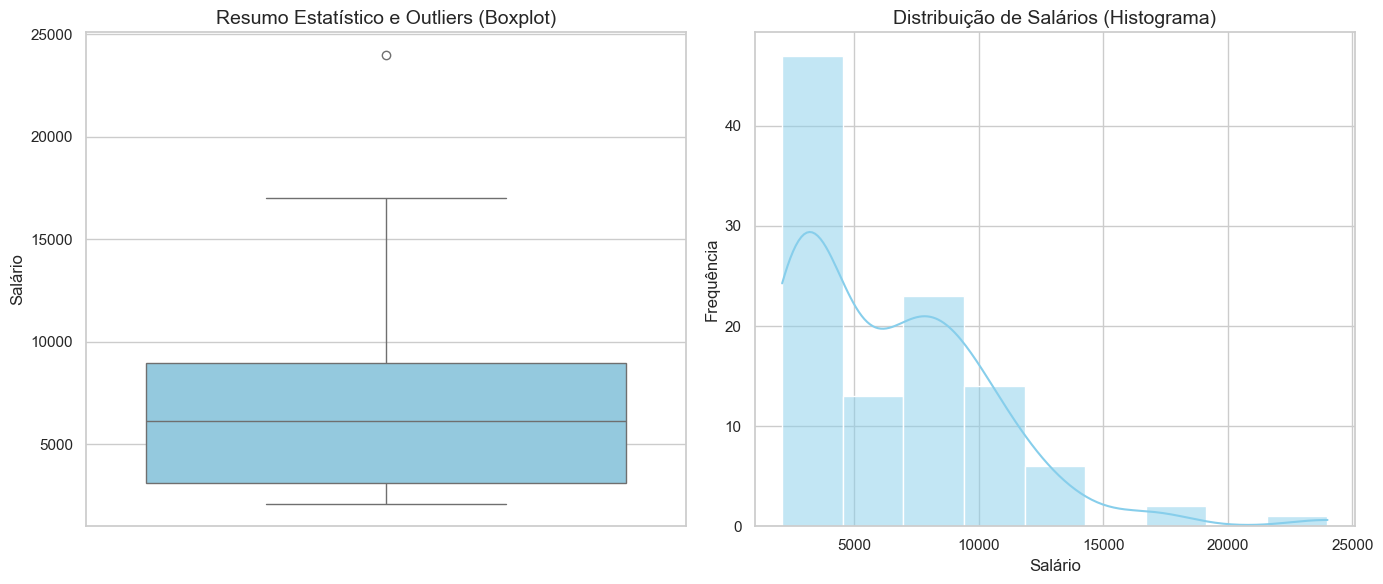

In [103]:

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# CONFIGURANDO BOXPLOT
sns.boxplot(
    data=df_salarios,
    y="SALARIO",  # Use x='salario' se preferir o boxplot deitado (horizontal)
    color="skyblue",
    ax=axes[0],  # Direciona o boxplot para o primeiro gráfico (esquerda)
)
axes[0].set_title("Resumo Estatístico e Outliers (Boxplot)", fontsize=14)
axes[0].set_ylabel("Salário", fontsize=12)
axes[0].set_xlabel("")

# CONFIGURANDO HISTOGRAMA 
sns.histplot(
    data=df_salarios,
    x="SALARIO",
    kde=True,  # Adiciona a linha de densidade
    color="skyblue",
    ax=axes[1],  
)
axes[1].set_title("Distribuição de Salários (Histograma)", fontsize=14)
axes[1].set_xlabel("Salário", fontsize=12)
axes[1].set_ylabel("Frequência", fontsize=12)

# 2. Ajuste automático para evitar sobreposição de elementos
plt.tight_layout()

# 3. Exibir a figura na tela
plt.show()

Podemos ver que a mediana não está bem centralizada no boxplot, o que indica que há uma concentração de até 50% até aproximadamente 6000 e cerca de 75% até 9000, o histograma corrobora essa informação mostrando uma concentração de quase 50 pessoas ganhando menos de 5000.

Depois podemos ver no Boxplot os extremos, sendo o extremo superior bem afastado e o outlier ainda mais. O histograma também auxilia a visualizar isso ao verificarmos que a linha vai descrescendo rapidamente.

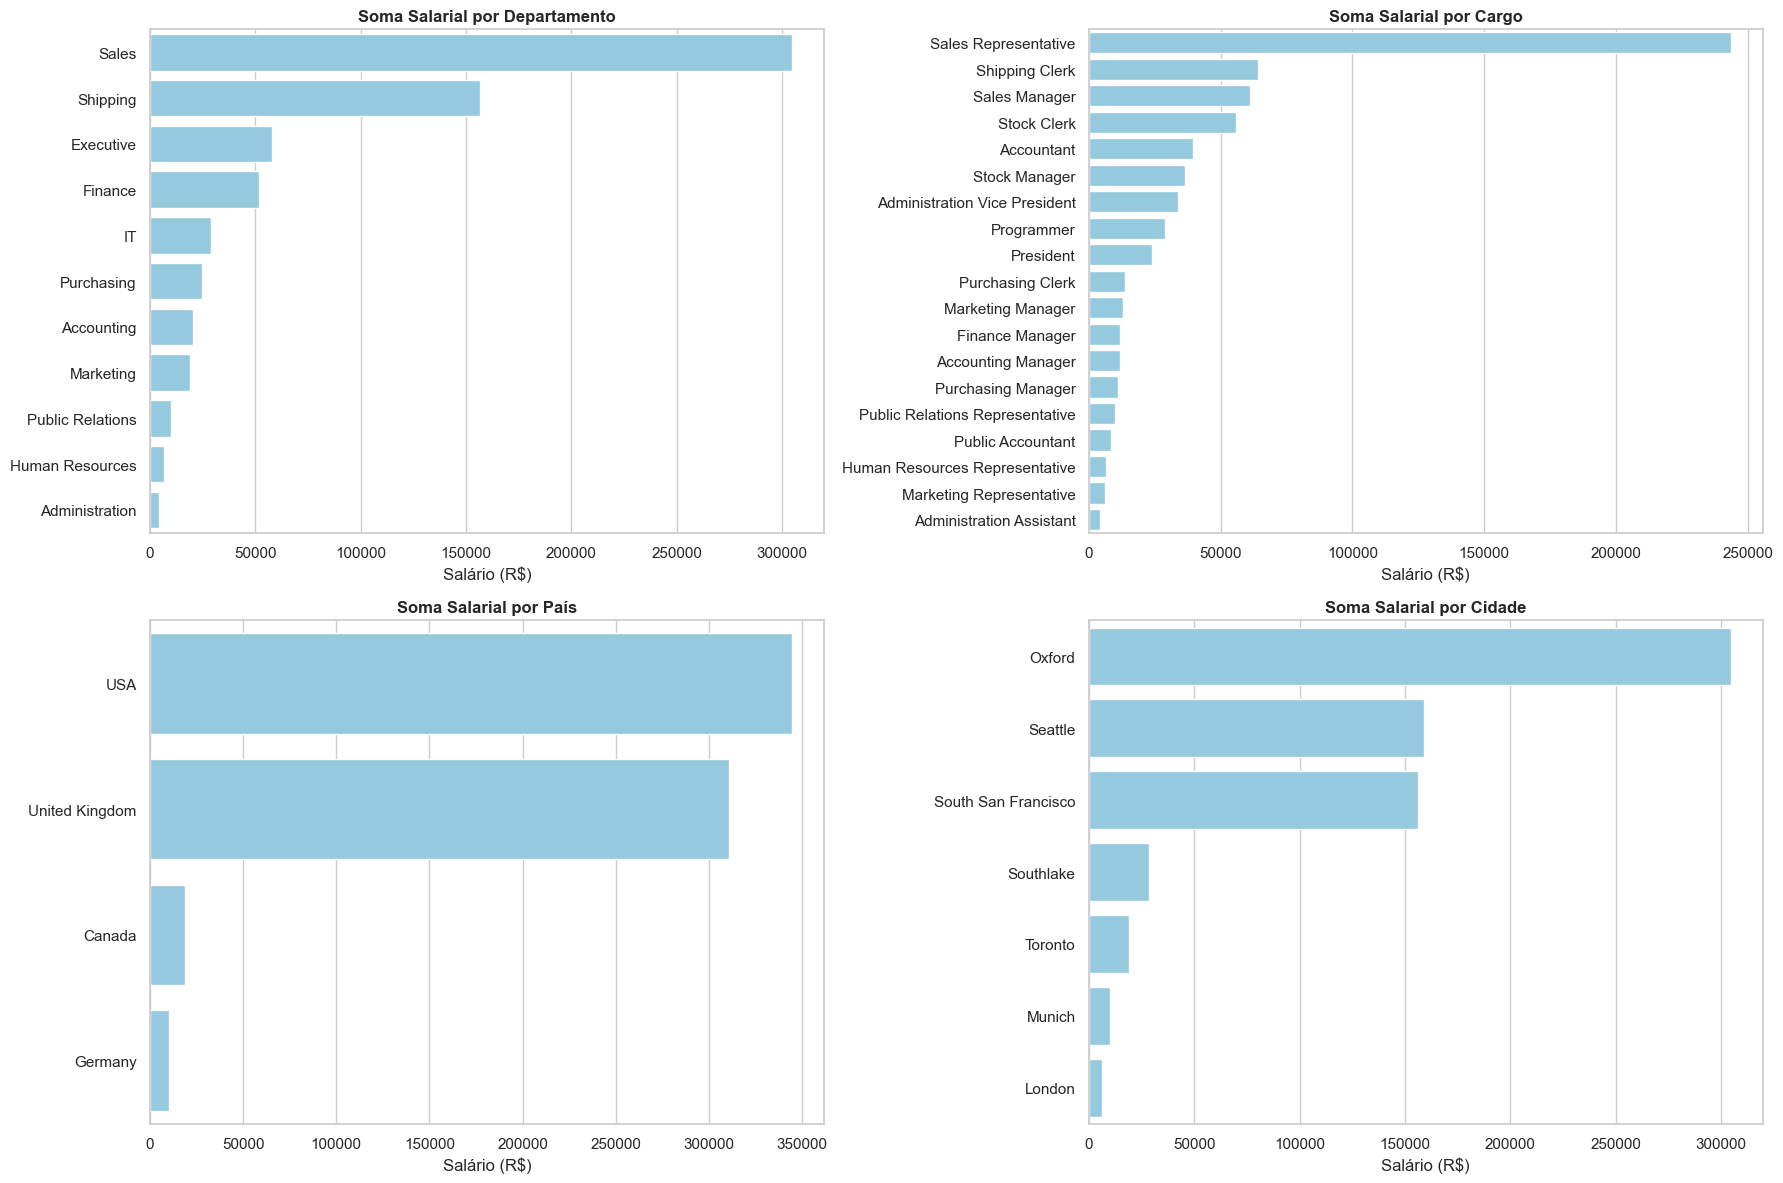

In [131]:

# Ajuste nomes
nomes_paises = {
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "United States of America": "USA",
}
df_grafico["PAIS"] = df_grafico["PAIS"].replace(
    nomes_paises
)


# Configuração de estilo limpo
sns.set_theme(style="whitegrid")

# Criando a estrutura 2x2 (2 linhas, 2 colunas) com bastante espaço lateral
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

# ---------------------------------------------------------
# 1. DEPARTAMENTO (Superior Esquerdo -> axes[0, 0])
# ---------------------------------------------------------
df_dept = df_grafico.groupby("DEPARTAMENTO")["SALARIO"].sum().reset_index()
df_dept = df_dept.sort_values(by="SALARIO", ascending=False)

sns.barplot(data=df_dept, x="SALARIO", y="DEPARTAMENTO", color="skyblue", ax=axes[0, 0])
axes[0, 0].set_title("Soma Salarial por Departamento", fontsize=12, weight='bold')
axes[0, 0].set_xlabel("Salário (R$)")
axes[0, 0].set_ylabel("") # Remove o título do eixo Y para economizar espaço

# ---------------------------------------------------------
# 2. CARGOS (Superior Direito -> axes[0, 1])
# ---------------------------------------------------------
df_cargos = df_grafico.groupby("CARGOS")["SALARIO"].sum().reset_index()
df_cargos = df_cargos.sort_values(by="SALARIO", ascending=False)

sns.barplot(data=df_cargos, x="SALARIO", y="CARGOS", color="skyblue", ax=axes[0, 1])
axes[0, 1].set_title("Soma Salarial por Cargo", fontsize=12, weight='bold')
axes[0, 1].set_xlabel("Salário (R$)")
axes[0, 1].set_ylabel("")

# ---------------------------------------------------------
# 3. PAIS (Inferior Esquerdo -> axes[1, 0])
# ---------------------------------------------------------
df_pais = df_grafico.groupby("PAIS")["SALARIO"].sum().reset_index()
df_pais = df_pais.sort_values(by="SALARIO", ascending=False)

sns.barplot(data=df_pais, x="SALARIO", y="PAIS", color="skyblue", ax=axes[1, 0])
axes[1, 0].set_title("Soma Salarial por País", fontsize=12, weight='bold')
axes[1, 0].set_xlabel("Salário (R$)")
axes[1, 0].set_ylabel("")

# ---------------------------------------------------------
# 4. CIDADE (Inferior Direito -> axes[1, 1])
# ---------------------------------------------------------
df_cidade = df_grafico.groupby("CIDADE")["SALARIO"].sum().reset_index()
df_cidade = df_cidade.sort_values(by="SALARIO", ascending=False)

sns.barplot(data=df_cidade, x="SALARIO", y="CIDADE", color="skyblue", ax=axes[1, 1])
axes[1, 1].set_title("Soma Salarial por Cidade", fontsize=12, weight='bold')
axes[1, 1].set_xlabel("Salário (R$)")
axes[1, 1].set_ylabel("")

# Ajuste fino para evitar sobreposição de títulos e rótulos
plt.tight_layout()
plt.show()

- Podemos ver no acumulado que por mais que não sejam os com maiores salários o setor de vendas mais acumula investimento com pessoal.
- USA e United Kingdom acumulam quase todos os gastos, dentro desses países o investimento se concentra nas cidades de oxford, seattle e South San Francisco.